# 05. First-Purchase Feature Analysis

## Objective

Build and evaluate customer features available at the first payment-approved purchase.

The analysis focuses on:

- first-order monetary value
- basket size and product diversity
- payment behavior
- product category
- customer region
- purchase timing
- differences in 90-day repeat-purchase rate

In [1]:
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Feature + Label
conn = sqlite3.connect(
    "../data/processed/olist.db"
)

analysis_df = pd.read_sql_query(
    """
    SELECT
        f.*,
        y.first_purchase_month,
        y.is_eligible_90d,
        y.repeat_90d_after_1h

    FROM first_purchase_feature_base AS f

    JOIN customer_repeat_90d_base AS y
        ON f.customer_unique_id
            = y.customer_unique_id

    WHERE
        y.is_eligible_90d = 1
    """,
    conn
)

conn.close()

In [3]:
# 구조 확인
print(
    analysis_df.shape
)

print()

print(
    analysis_df[
        "repeat_90d_after_1h"
    ]
    .value_counts()
)

print()

print(
    analysis_df.isna()
    .sum()
    .sort_values(
        ascending=False
    )
)

(78505, 25)

repeat_90d_after_1h
0    77423
1     1082
Name: count, dtype: int64

primary_category                  1877
first_item_count                   578
first_seller_count                 578
missing_category_item_count        578
first_avg_item_price               578
first_freight_value                578
first_order_value                  578
first_item_value                   578
first_distinct_product_count       578
first_category_count               578
first_freight_ratio                578
first_payment_value                  1
first_payment_type_count             1
first_max_payment_installments       1
primary_payment_type                 1
first_payment_record_count           1
customer_unique_id                   0
purchase_hour                        0
first_approved_at                    0
customer_state                       0
purchase_weekday                     0
first_order_id                       0
first_purchase_month                 0
is_eligible_90d      

In [4]:
# 첫 구매금액 Quartile
analysis_df[
    "order_value_group"
] = pd.qcut(
    analysis_df[
        "first_order_value"
    ],
    q=4,
    labels=[
        "Q1",
        "Q2",
        "Q3",
        "Q4"
    ]
)

In [5]:
value_group_df = (
    analysis_df
    .groupby(
        "order_value_group",
        observed=True
    )
    ["repeat_90d_after_1h"]
    .agg(
        [
            "count",
            "sum",
            "mean"
        ]
    )
)

print(value_group_df)

                   count  sum      mean
order_value_group                      
Q1                 19530  279  0.014286
Q2                 19488  266  0.013649
Q3                 19433  258  0.013276
Q4                 19476  271  0.013915


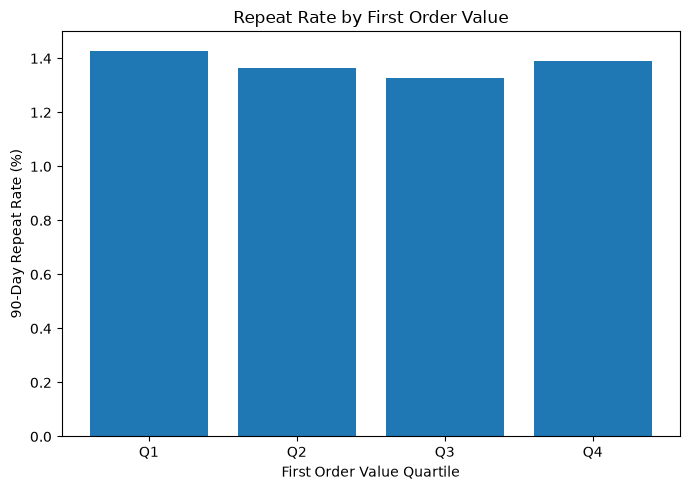

In [6]:
# 첫 구매액과 재구매율
value_group_plot_df = (
    value_group_df
    .reset_index()
)

value_group_plot_df[
    "repeat_rate_pct"
] = (
    value_group_plot_df[
        "mean"
    ]
    * 100
)

plt.figure(
    figsize=(7, 5)
)

plt.bar(
    value_group_plot_df[
        "order_value_group"
    ],
    value_group_plot_df[
        "repeat_rate_pct"
    ]
)

plt.xlabel(
    "First Order Value Quartile"
)

plt.ylabel(
    "90-Day Repeat Rate (%)"
)

plt.title(
    "Repeat Rate by First Order Value"
)

plt.tight_layout()

plt.savefig(
    "../reports/figures/"
    "first_order_value_repeat_rate.png"
)

plt.show()

In [7]:
# Basket Size 분석
item_analysis_df = (
    analysis_df[
        analysis_df[
            "first_item_count"
        ].notna()
    ]
    .copy()
)

item_analysis_df[
    "multi_item_order"
] = (
    item_analysis_df[
        "first_item_count"
    ] >= 2
)

item_group_df = (
    item_analysis_df
    .groupby(
        "multi_item_order"
    )
    ["repeat_90d_after_1h"]
    .agg(
        [
            "count",
            "sum",
            "mean"
        ]
    )
)

print(item_group_df)

                  count  sum      mean
multi_item_order                      
False             70197  925  0.013177
True               7730  149  0.019276


In [8]:
# Payment Type
payment_repeat_df = (
    analysis_df
    .groupby(
        "primary_payment_type"
    )
    ["repeat_90d_after_1h"]
    .agg(
        [
            "count",
            "sum",
            "mean"
        ]
    )
    .sort_values(
        "count",
        ascending=False
    )
)

print(payment_repeat_df)

                      count  sum      mean
primary_payment_type                      
credit_card           59297  817  0.013778
boleto                15900  208  0.013082
voucher                2481   44  0.017735
debit_card              826   13  0.015738


In [9]:
# Category
category_repeat_df = (
    analysis_df
    .groupby(
        "primary_category"
    )
    ["repeat_90d_after_1h"]
    .agg(
        [
            "count",
            "sum",
            "mean"
        ]
    )
    .sort_values(
        "count",
        ascending=False
    )
)

category_repeat_df.head(20)

,count,sum,mean
primary_category,,,
cama_mesa_banho,7323,151,0.020620
beleza_saude,6408,83,0.012953
esporte_lazer,6238,113,0.018115
informatica_acessorios,5394,48,0.008899
moveis_decoracao,5147,93,0.018069
utilidades_domesticas,4262,52,0.012201
relogios_presentes,4194,57,0.013591
telefonia,3476,42,0.012083
brinquedos,3322,39,0.011740


In [10]:
# Region
state_repeat_df = (
    analysis_df
    .groupby(
        "customer_state"
    )
    ["repeat_90d_after_1h"]
    .agg(
        [
            "count",
            "sum",
            "mean"
        ]
    )
    .sort_values(
        "count",
        ascending=False
    )
)

state_repeat_df

,count,sum,mean
customer_state,,,
SP,32135,483,0.015030
RJ,10377,150,0.014455
MG,9317,123,0.013202
RS,4433,56,0.012633
PR,3986,41,0.010286
SC,2958,30,0.010142
BA,2712,35,0.012906
DF,1644,22,0.013382
GO,1636,22,0.013447
